In [1]:
%load_ext autoreload
%autoreload 2 --print

In [1]:
import torch as th
import torch.jit as jit
import copy
import numpy as np
import dill
from collections import namedtuple
from torch import optim
from torch import nn
from dynrn.rnntasks import (
    DriscollTasks,
    DriscollPlots,
    period_start_mask,
    periwindows,
    periperiod_sliced,
    split_trials,
    extract_trial_data,
    apply_to_trial_groups,
    nanmean_with_req,
    split_trials_driscoll,
)
from dynrn.predictors import (
    activity_dataset,
    save_dsn,
    load_dsn,
    discounted_sums,
    MultiBlockActivityDataset,
)
import dynrn.predictors as pred
import dynrn.basic_rnns as rnns
from dynrn.basic_rnns import find_hash
from dynrn.viz import dynamics as vd
import scipy.stats
from cmap import Colormap
from scipy.stats import uniform, norm
from datetime import datetime
from mplutil import util as vu
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.decomposition import PCA
import tqdm
from numpy import linalg as la
import os
import joblib as jl
import time
import seaborn as sns

In [2]:
from dynrn.viz import styles
from dynrn.viz.styles import getc
t20 = lambda x: getc(f"seaborn:tab20{x}")
colors, plotter = styles.init_plt(
    Path('../plots/notebook/multi-pred-failure').resolve(),
    fmt = 'pdf', display=False)
plot_root = Path(plotter.plot_dir)

period_colors = {
    "iti": t20("b:5"),
    "context": t20("c:1"),
    "stim": t20("b:2"),
    "memory": t20("b:14"),
    "response": t20("b:10")
}

In [3]:
# cuda setup
device = th.device('cuda' if th.cuda.is_available() else 'cpu')
cpu = th.device('cpu' if th.cuda.is_available() else 'cpu')
print(device.type)

cpu


### Load predictions

In [82]:
root_dir = "/Users/kaifox/projects/loop/dynrn/data"
dsn_hash = '7d4c5e'

# load discounted sum network pointed to by hash
dsn_path = find_hash(root_dir, dsn_hash, ".pt")
dsn_path = Path(str(dsn_path)[:-3])  # remove .pt
final_dsn, dsn_ckpts, traindata = rnns.load_rnn(dsn_path, device=device)
print("loaded dsn:", dsn_path.name)

# Load associated activity dataset
act_data_hash = traindata["act_hash"]
# act_data_hash = '<hash>'
act_path = find_hash(root_dir, act_data_hash, ".dil")
act_data = dill.load(open(act_path, "rb"))
print("loaded avtivity data:", Path(act_path).name)

# Select main variables from activity dataset
test_data: MultiBlockActivityDataset = act_data["test"]
test_blocks = DriscollTasks.split_dataset(test_data)
cumulant_fn = lambda x: x[:, 1:]
gamma = traindata["gamma"]

# set plotting directory
dsn_name = dsn_path.name
nb_plot_dir = Path('../plots/notebook').resolve()
plotter.plot_dir = nb_plot_dir / 'multi-pred-failure' / dsn_name
plotter.plot_dir.mkdir(exist_ok=True)

loaded dsn: mems-def-long-lr20-w256_7d4c5e
loaded avtivity data: mems-def-long-lr20_7d4c35.dil


In [83]:
# discounted sum predictions
x = th.tensor(test_data["activity"], dtype=th.float32, device=device)
preds = final_dsn.to(device)(x).cpu().detach().numpy()

# extraction of cumulant from sum
cumul_gt = cumulant_fn(test_data["activity"])
# V(h_t) approx cumulant(t) + gamma * V(h_{t+1})
cumul_pr = preds[:, :-1] - gamma * preds[:, 1:]

# ground truth sums, V(h_t) = sum_{k=0..} gamma^k h_{t+k+1}
sums_gt = pred.discounted_sums(cumul_gt, gamma)
sums_pr = preds[:, :-1]

# timepoint-wise loss
loss_series = la.norm(cumul_gt - cumul_pr, axis=-1)

### Background info

/Users/kaifox/projects/loop/dynrn/plots/notebook/multi-pred-failure/mems-def-long-lr20-w256_7d4c5e/period-durations.pdf


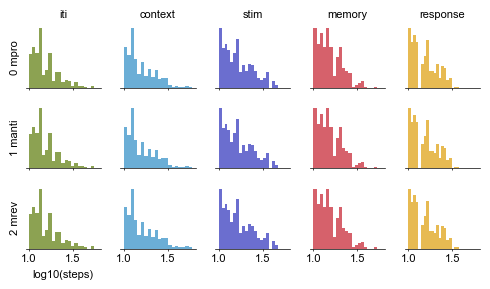

In [84]:
durations = {
    i_b: {
        p: [t["durations"][i_p] for s in b["trials"] for t in s]
        for i_p, p in enumerate(b["task"].periods)
    }
    for i_b, b in enumerate(test_blocks)
}


def _plot():
    npr = max(t.n_period for t in test_data["block_tasks"])
    nbl = len(test_blocks)
    fig, ax = plt.subplots(nbl, npr, figsize=(1 * npr, 1 * nbl), sharex=True)
    for bl in range(nbl):
        for i, p in enumerate(test_blocks[bl]["task"].periods):
            ax[bl, i].hist(np.log10(durations[bl][p]), bins=20, color=period_colors[p])
            ax[0, i].set_title(p, fontsize=8)
            b_task = test_blocks[bl]["task"]
            ax[bl, 0].set_ylabel(f"{bl} {b_task.short_name}")
            ax[bl, i].set_yticks([])
            sns.despine(ax=ax[bl, i], left=True)
    # ax[0, 0].set_xlim(0, None)
    ax[-1, 0].set_xlabel("log10(steps)")
    return fig


_f = _plot()
plotter.finalize(_f, "period-durations", despine=False)

### Loss relative to trial start

In [85]:
# indexing: period_block_loss[i_block][period_number]: DataFrame[rel_time, number, 0, 1, 2, ...]
# where column "0" indexes last dimension of `loss_series`

period_block_loss = {}
for i_block, slc in enumerate(test_data['block_slices']):
    period_block_loss[i_block] = periperiod_sliced(
        loss_series[slc, :, None],
        test_data['periods'][slc, 1:].astype('int')
    )

/Users/kaifox/projects/loop/dynrn/plots/notebook/multi-pred-failure/mems-def-long-lr20-w256_7d4c5e/periperiod-losses.pdf


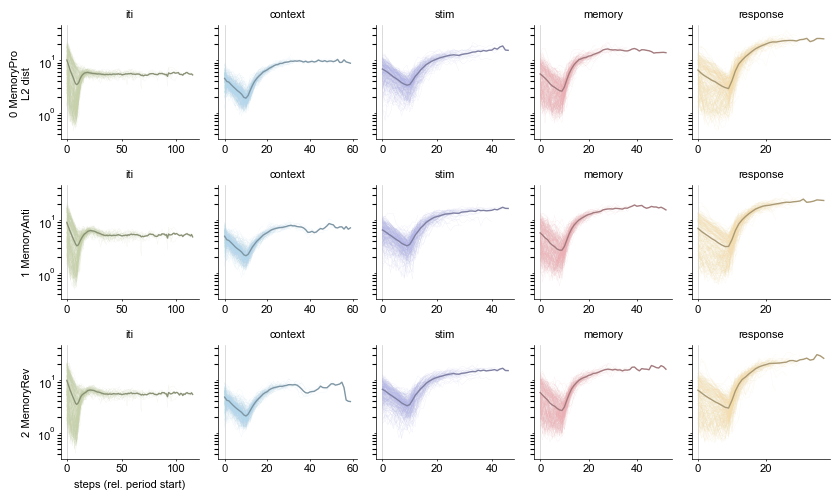

In [86]:
def _plot():
    npr = max(t.n_period for t in test_data['block_tasks'])
    nbl = len(test_data['block_slices'])
    fig, ax = plt.subplots(nbl, npr, figsize=(1.7 * npr, nbl * 1.7), sharey=True)
    for i_b, b_task in enumerate(test_data['block_tasks']):
        for i_p, p_name in enumerate(b_task.periods):
            block = period_block_loss[i_b][i_p]
            c = vu.lighten(period_colors[p_name], 0.5)
            a = ax[i_b, i_p]
            block = block[block.rel_time >= 0]
            for k, group in block.groupby('number'):
                a.plot(
                    group.rel_time, group[0], color=c, lw=0.05
                )
            means = block.groupby('rel_time').mean()[0]
            a.plot(means, color=vu.darken(c, 0.3), lw = 1)
            a.axvline(0, color = colors.subtle, lw = 0.5, zorder = -2)
            a.set_title(p_name, fontsize=8)
            a.set_yscale('log')
            if i_b == 0 and i_p == 0:
                a.set_ylabel(f"{i_b} {b_task.name}\nL2 dist")
            elif i_p == 0:
                a.set_ylabel(f"{i_b} {b_task.name}")
        for i_p in range(b_task.n_period, npr):
            ax[i_b, i_p].set_axis_off()
    ax[-1, 0].set_xlabel("steps (rel. period start)")
    return fig
_f = _plot(); plotter.finalize(_f, 'periperiod-losses')

### Period-wise PCA and dymamics

In [87]:
# find task-wise, period-wise PCs

# shorthand for pca.transform on high-dim array
_pct = lambda pca, x: pca.transform(x.reshape(-1, x.shape[-1])).reshape(
    x.shape[:-1] + (pca.n_components_,)
)

def _calc(task, slc, gt, pred):
    # list of trials, where each trial is dict of lists of arrays
    # ex: trials[0]['period'] = [[4, 0, 1], [0, 1, 2], ..., [3, 4, 0]]
    # and trials[0]['gt'] has same list strucutre, but with period indices
    # replaced by `cumulpc_gt` data from the corresponding period
    trials_fulldim = split_trials(
        {"gt": gt[slc]},
        test_data['periods'][slc].astype("int")[:, 1:],
    )
    trials_fulldim = list(
        filter(  # filter out end-of-session ITI
            (lambda t: len(t["period"]) >= 5), trials_fulldim
        )
    )
    # fit pca for activity during each period for visualization
    _npr = task.n_period
    period_gt = [
        np.concatenate([t["gt"][i] for t in trials_fulldim]) for i in range(_npr)
    ]
    period_cumul_pca = [PCA(n_components=3).fit(h) for h in period_gt]
    full_pca = PCA(n_components=3).fit(gt.reshape(-1, gt.shape[-1]))

    # gt and predicted cumulants and predicted future sum, projected onto each PC axis
    # shape: (n_sessions, session_length, 2, n_period)
    cumulpc_gt = np.stack(
        [_pct(pca, gt[slc]) for pca in period_cumul_pca],
        axis=-1,
    )
    cumulpc_pr = np.stack(
        [_pct(pca, pred[slc]) for pca in period_cumul_pca],
        axis=-1,
    )

    cumulfpc_gt = _pct(full_pca, gt[slc])
    cumulfpc_pr = _pct(full_pca, pred[slc])

    return period_cumul_pca, cumulpc_gt, cumulpc_pr, cumulfpc_gt, cumulfpc_pr

period_pca, cumulpc_gt, cumulpc_pr, cumulfpc_gt, cumulfpc_pr = {}, {}, {}, {}, {}
sum_period_pca, sumpc_gt, sumpc_pr, sumfpc_gt, sumfpc_pr = {}, {}, {}, {}, {}
for i, (_t, _s) in enumerate(zip(test_data['block_tasks'], test_data['block_slices'])):
    _p, _g, _r, _fg, _fr = _calc(_t, _s, cumul_gt, cumul_pr)
    period_pca[i] = _p
    cumulpc_gt[i] = _g
    cumulpc_pr[i] = _r
    cumulfpc_gt[i] = _fg
    cumulfpc_pr[i] = _fr
    _p, _g, _r, _fg, _fr = _calc(_t, _s, sums_gt, sums_pr)
    period_pca[i] = _p
    sumpc_gt[i] = _g
    sumpc_pr[i] = _r
    sumfpc_gt[i] = _fg
    sumfpc_pr[i] = _fr

In [88]:
def _calc(block, task, slc, pc_gt, pc_pred, fullpc_gt, fullpc_pred):
    # recover activity from cumulants
    actpc = np.concatenate([np.full_like(pc_gt[block][:, [0]], np.nan), pc_gt[block]], axis=1)
    factpc = np.concatenate([np.full_like(fullpc_gt[block][:, [0]], np.nan), fullpc_gt[block]], axis=1)
    
    # recover predicted activity from cumulants
    practpc = np.concatenate([np.full_like(pc_pred[block][:, [0]], np.nan), pc_pred[block]], axis=1)
    practfpc = np.concatenate([np.full_like(fullpc_pred[block][:, [0]], np.nan), fullpc_pred[block]], axis=1)

    # list of trials, where each trial is dict of lists of arrays
    # ex: trials['period'][0] = [[4, 0, 1], [0, 1, 2], ..., [3, 4, 0]]
    # and trials['pc_gt'][0] has same list strucutre, but with period indices
    # replaced by `pc_gt` data from the corresponding period
    trials = split_trials_driscoll(
        {
            "actpc": actpc,
            "factpc": factpc,
            "practpc": practpc,
            "practfpc": practfpc,
            "stim": test_data['stimuli'][slc],
        },
        test_blocks[block],
        window=1,
    )

    # find stim angle for each trial and group by it
    trial_angles, trial_angle_colors, trial_groups = extract_trial_data(
        lambda x: np.arctan2(x[:, 3], x[:, 2]).mean(),
        trials,
        window = 1,
        cmap = Colormap("matlab:cool"),
        color_range = (0, np.pi / 2),
        n_clusters = 20
    )
    trial_group_angles = np.array([trial_angles[group].mean() for group in trial_groups])
    trial_group_angle_colors = Colormap("matlab:cool")(trial_group_angles / np.pi * 4)

    return trials, trial_angle_colors, trial_group_angle_colors


trials, trial_colors, avg_trial_colors = {}, {}, {}
sum_trials, sumtrial_colors, avg_sumtrial_colors = {}, {}, {}
for _i, (_t, _s) in enumerate(zip(test_data['block_tasks'], test_data['block_slices'])):
    _t, _tc, _atc = _calc(_i, _t, _s, cumulpc_gt, cumulpc_pr, cumulfpc_gt, cumulfpc_pr)
    trials[_i] = _t
    trial_colors[_i] = _tc
    # avg_trials[_i] = _at
    avg_trial_colors[_i] = _atc

    _t, _tc, _atc = _calc(_i, _t, _s, sumpc_gt, sumpc_pr, sumfpc_gt, sumfpc_pr)
    sum_trials[_i] = _t
    sumtrial_colors[_i] = _tc
    avg_sumtrial_colors[_i] = _atc


In [89]:
period_timepals = {
    i_b: [
        Colormap([vu.lighten(c, 0.7), c, vu.darken(c, 0.6)])(
            np.linspace(0, 1, 15)
        )
        for c in [period_colors[n] for n in t.periods]
    ]
    for i_b, t in enumerate(test_data["block_tasks"])
}
angle_timepal = lambda c: (
    Colormap([vu.lighten(c, 0.6), c, vu.darken(c, 0.4)])(np.linspace(0, 1, 15))
)

### Period-wise dynamics plots: cumulant

/Users/kaifox/projects/loop/dynrn/plots/notebook/multi-pred-failure/mems-def-long-lr20-w256_7d4c5e/true-traj_period-pca.pdf


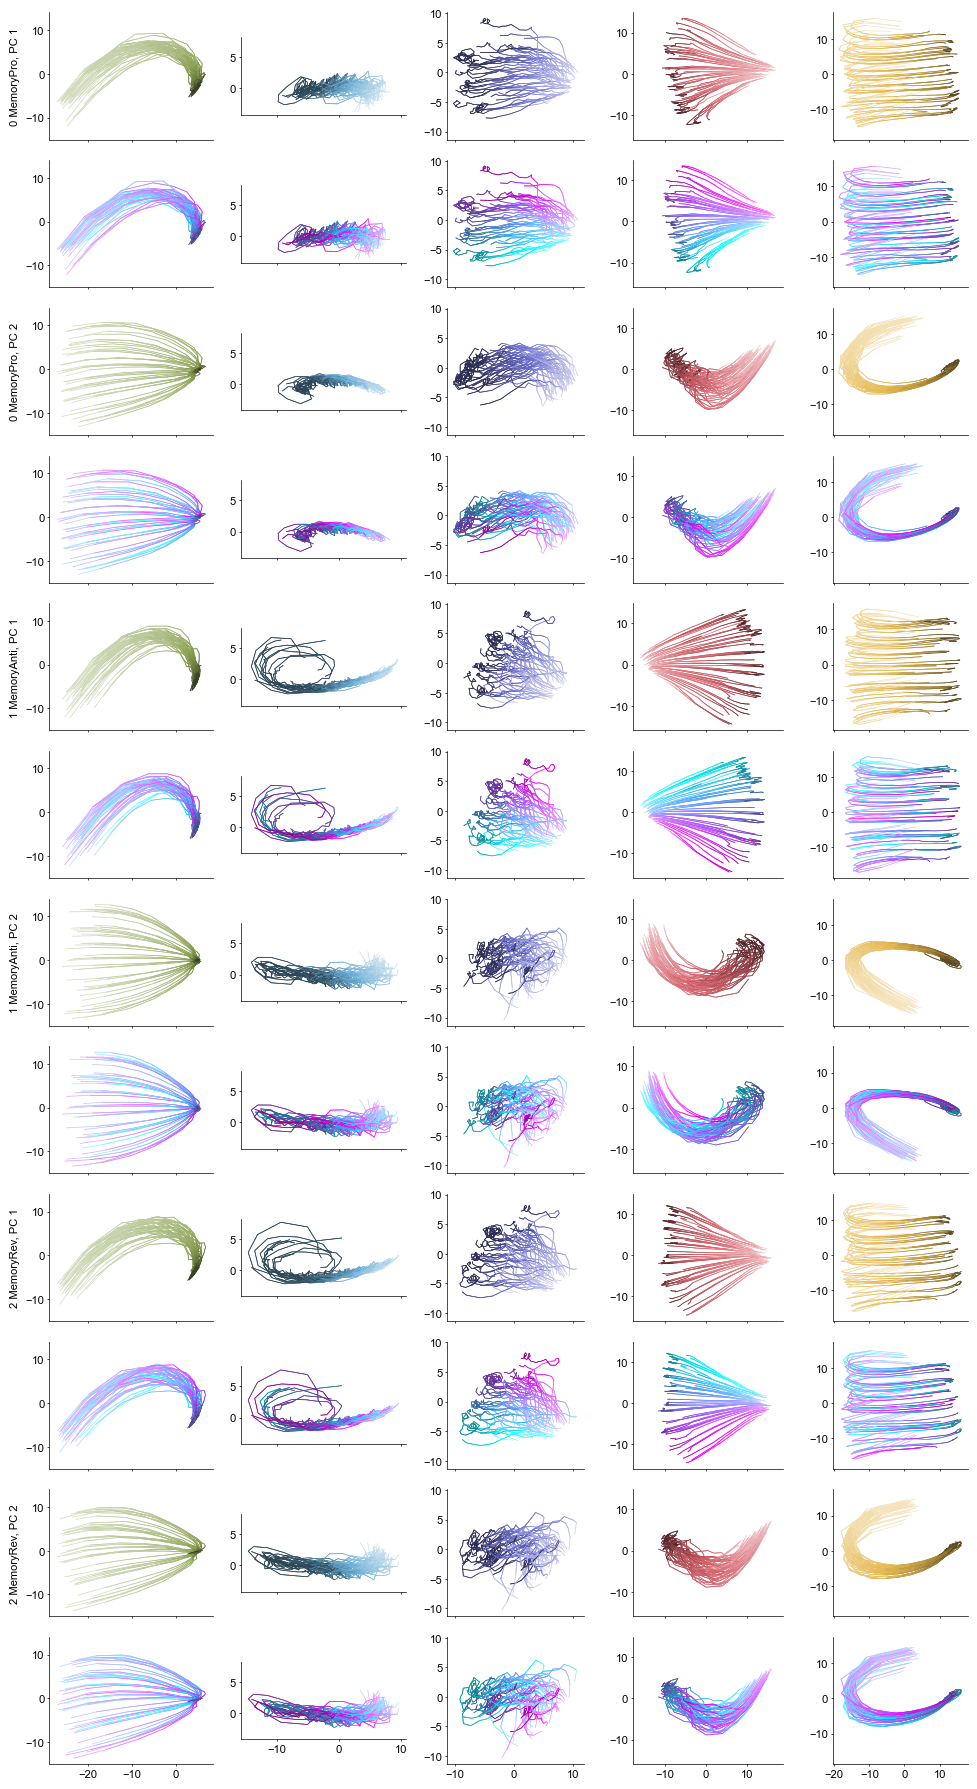

In [90]:
def _plot():
    nbl = len(test_data["block_slices"])
    fig, axes = plt.subplots(
        4 * nbl, 5, figsize=(2 * 5, 4 * 1.5 * nbl), sharex="col", sharey="col"
    )
    for i_b, task in enumerate(test_data["block_tasks"]):
        for i_y, y in enumerate([1, 2]):
            ax = axes[4 * i_b + 2 * i_y : 4 * i_b + 2 * i_y + 2]
            angle_timepals = [angle_timepal(c) for c in trial_colors[i_b]]

            plot_n = 50
            for i_win in [1]:
                for i_per in range(5):
                    # trials[key][i_trial][i_period, i_in_window][..., i_pc, i_pca]
                    tcolor = [
                        period_timepals[i_b][int(t[i_per, i_win])]
                        for t in trials[i_b]["period"][:plot_n]
                        if t[i_per, i_win] is not None
                    ]
                    tdata = [
                        t[i_per, i_win][..., [0, y], i_per]
                        for it, t in enumerate(trials[i_b]["actpc"][:plot_n])
                        if trials[i_b]["period"][it][i_per, i_win] is not None
                    ]
                    vd.trajecories(
                        ax[0, i_per],
                        tdata,
                        tcolor,
                        color="both",
                        lw=0.5,
                    )

                    vd.trajecories(
                        ax[1, i_per],
                        tdata,
                        angle_timepals[:plot_n],
                        color="both",
                        lw=0.5,
                    )

            ax[0, 0].set_ylabel(f"{i_b} {task.name}, PC {y}")
    return fig


_fig = _plot()
plotter.finalize(_fig, "true-traj_period-pca")

/Users/kaifox/projects/mplutils/mplutil/nb.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


/Users/kaifox/projects/loop/dynrn/plots/notebook/multi-pred-failure/mems-def-long-lr20-w256_7d4c5e/true-traj_period-pca_3d.pdf


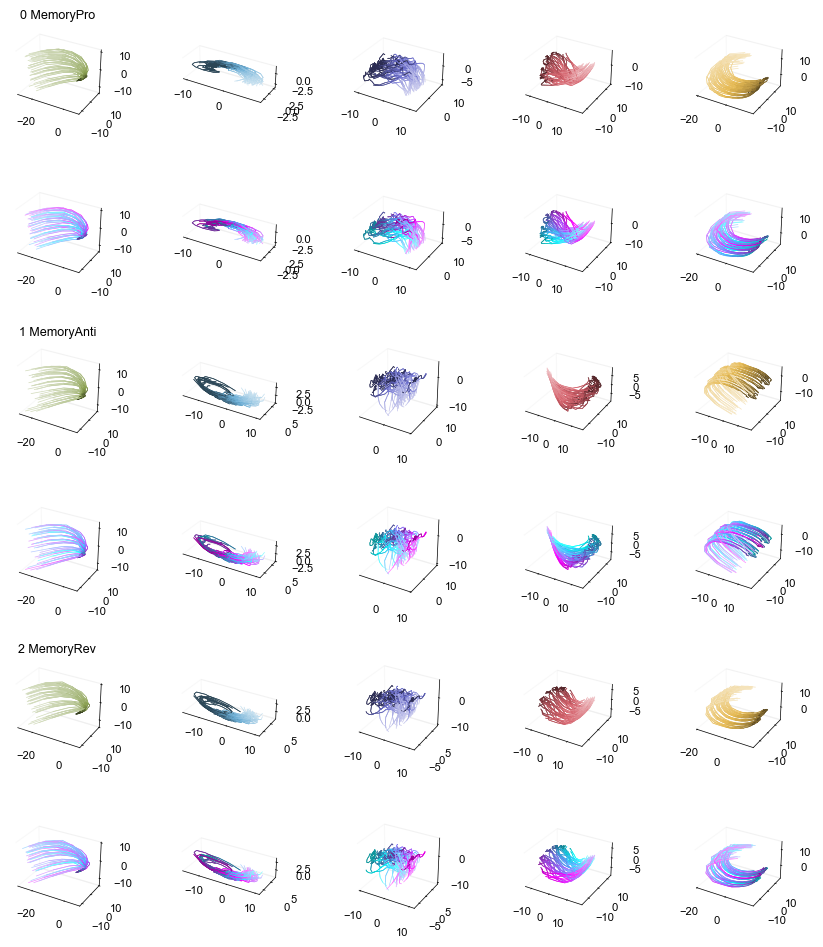

In [91]:
def _plot():
    nbl = len(test_data["block_slices"])
    fig, axes = plt.subplots(
        2 * nbl, 5, figsize=(2 * 5, 2 * 2 * nbl), subplot_kw={"projection": "3d"}, gridspec_kw={'wspace': 0.8}
    )
    for i_b, task in enumerate(test_data["block_tasks"]):
            ax = axes[2 * i_b : 2 * i_b + 2]
            angle_timepals = [angle_timepal(c) for c in trial_colors[i_b]]

            plot_n = 50
            for i_win in [1]:
                for i_per in range(5):
                    # trials[key][i_trial][i_period, i_in_window][..., i_pc, i_pca]
                    tcolor = [
                        period_timepals[i_b][int(t[i_per, i_win])]
                        for t in trials[i_b]["period"][:plot_n]
                        if t[i_per, i_win] is not None
                    ]
                    tdata = [
                        t[i_per, i_win][..., :3, i_per]
                        for it, t in enumerate(trials[i_b]["actpc"][:plot_n])
                        if trials[i_b]["period"][it][i_per, i_win] is not None
                    ]
                    vd.trajecories(
                        ax[0, i_per],
                        tdata,
                        tcolor,
                        color="both",
                        lw=0.5,
                    )

                    vd.trajecories(
                        ax[1, i_per],
                        tdata,
                        angle_timepals[:plot_n],
                        color="both",
                        lw=0.5,
                    )

            ax[0, 0].set_title(f"{i_b} {task.name}")
    return fig


_fig = _plot()
plotter.finalize(_fig, "true-traj_period-pca_3d")

/Users/kaifox/projects/loop/dynrn/plots/notebook/multi-pred-failure/mems-def-long-lr20-w256_7d4c5e/true-traj_full-pca.pdf


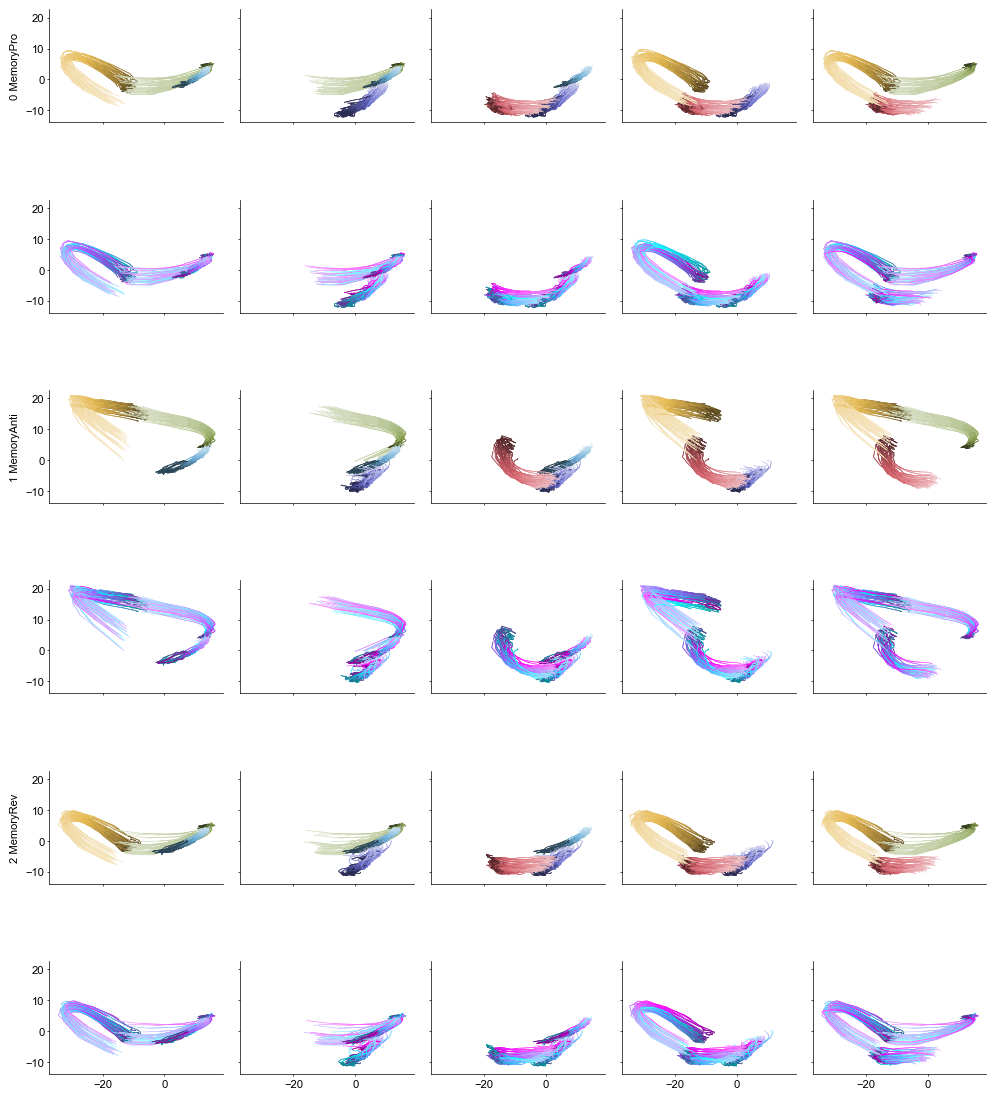

In [92]:
def _plot():
    nbl = len(test_data["block_slices"])
    fig, axes = plt.subplots(
        2 * nbl, 5, figsize=(2 * 5, 2 * 2 * nbl), sharex=True, sharey=True
    )
    for i_b, task in enumerate(test_data["block_tasks"]):
        ax = axes[2 * i_b : 2 * i_b + 2]
        angle_timepals = [angle_timepal(c) for c in trial_colors[i_b]]

        plot_n = 50
        for i_win in range(3):
            for i_per in range(5):
                # trials[key][i_trial][i_period, i_in_window][..., i_pc]
                tcolor = [
                    period_timepals[i_b][int(t[i_per, i_win])]
                    for t in trials[i_b]["period"][:plot_n]
                    if t[i_per, i_win] is not None
                ]
                tdata = [
                    t[i_per, i_win][..., :2]
                    for it, t in enumerate(trials[i_b]["factpc"][:plot_n])
                    if trials[i_b]["period"][it][i_per, i_win] is not None
                ]
                vd.trajecories(
                    ax[0, i_per],
                    tdata,
                    tcolor,
                    color="both",
                    lw=0.5,
                )

                vd.trajecories(
                    ax[1, i_per],
                    tdata,
                    angle_timepals[:plot_n],
                    color="both",
                    lw=0.5,
                )

        ax[0, 0].set_ylabel(f"{i_b} {task.name}")
    return fig


_fig = _plot()
plotter.finalize(_fig, "true-traj_full-pca")

/Users/kaifox/projects/mplutils/mplutil/nb.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


/Users/kaifox/projects/loop/dynrn/plots/notebook/multi-pred-failure/mems-def-long-lr20-w256_7d4c5e/true-traj_full-pca_3d.pdf


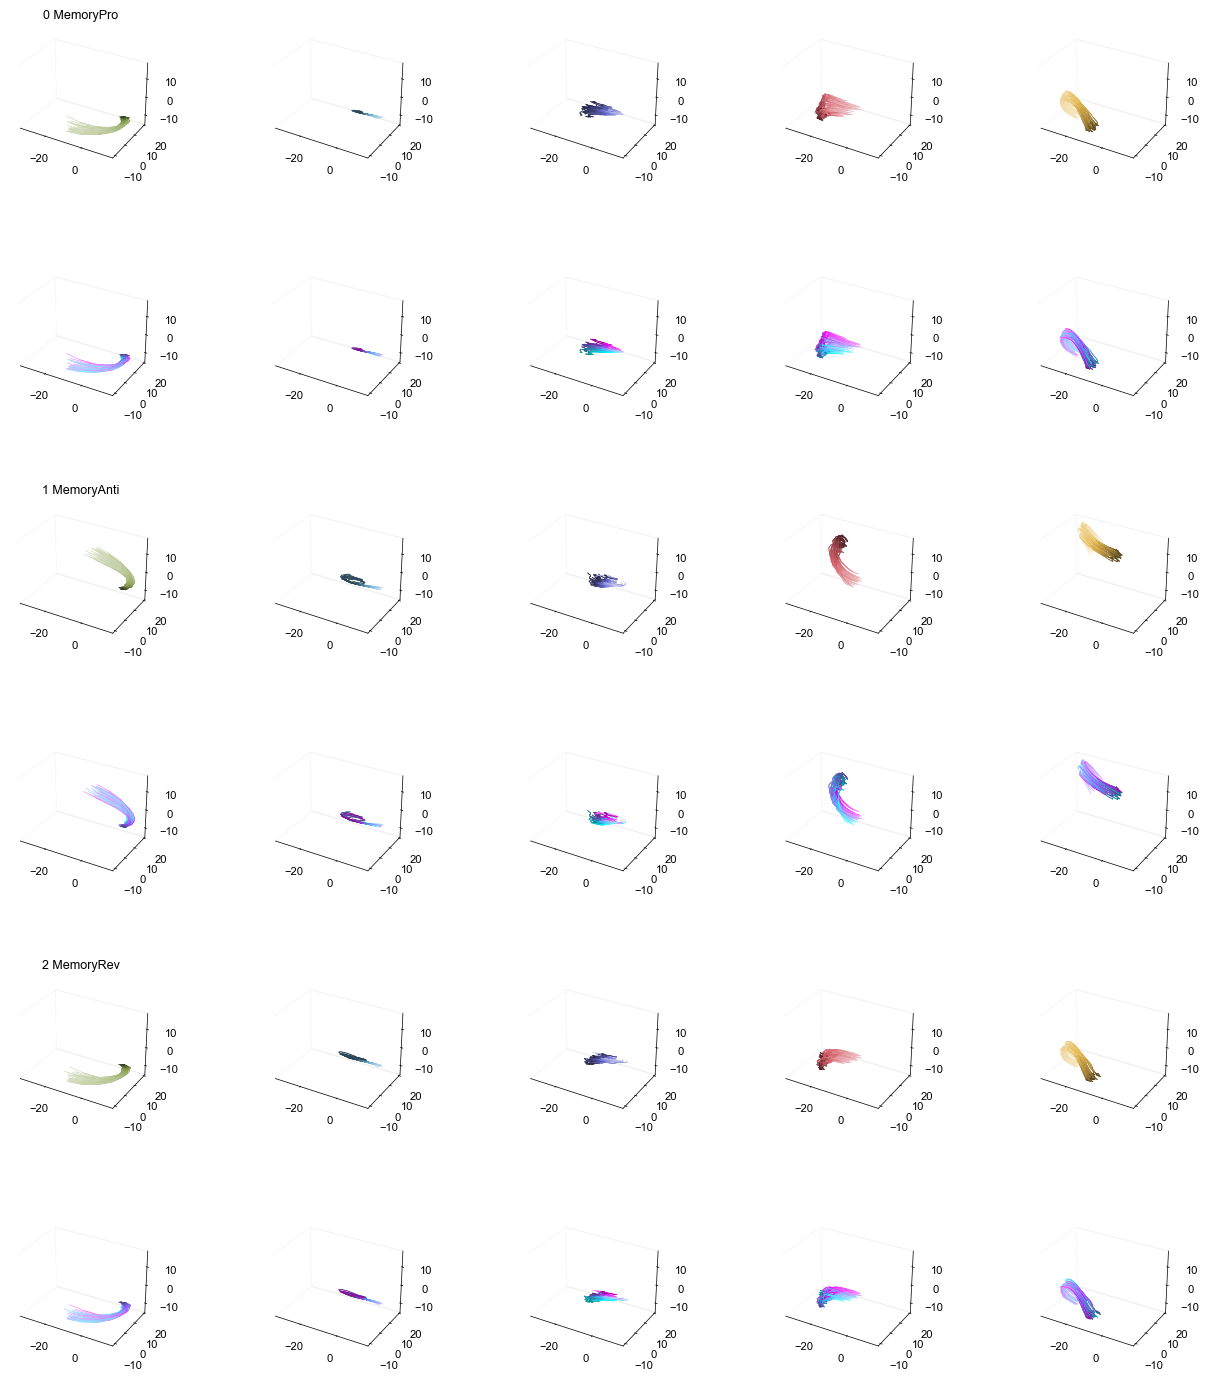

In [93]:
def _plot():
    nbl = len(test_data["block_slices"])
    fig, axes = plt.subplots(
        2 * nbl, 5, figsize=(3 * 5, 2 * 3 * nbl), subplot_kw={"projection": "3d"}, gridspec_kw={'wspace': 0.8}
    )
    xmin, xmax = np.inf, -np.inf
    ymin, ymax = np.inf, -np.inf
    zmin, zmax = np.inf, -np.inf
    for i_b, task in enumerate(test_data["block_tasks"]):
            ax = axes[2 * i_b : 2 * i_b + 2]
            angle_timepals = [angle_timepal(c) for c in trial_colors[i_b]]

            plot_n = 50
            for i_win in [1]:
                for i_per in range(5):
                    # trials[key][i_trial][i_period, i_in_window][..., i_pc, i_pca]
                    tcolor = [
                        period_timepals[i_b][int(t[i_per, i_win])]
                        for t in trials[i_b]["period"][:plot_n]
                        if t[i_per, i_win] is not None
                    ]
                    tdata = [
                        t[i_per, i_win][..., :3]
                        for it, t in enumerate(trials[i_b]["factpc"][:plot_n])
                        if trials[i_b]["period"][it][i_per, i_win] is not None
                    ]
                    xmin = min(xmin, min(t[:, 0].min() for t in tdata))
                    xmax = max(xmax, max(t[:, 0].max() for t in tdata))
                    ymin = min(ymin, min(t[:, 1].min() for t in tdata))
                    ymax = max(ymax, max(t[:, 1].max() for t in tdata))
                    zmin = min(zmin, min(t[:, 2].min() for t in tdata))
                    zmax = max(zmax, max(t[:, 2].max() for t in tdata))
                    vd.trajecories(
                        ax[0, i_per],
                        tdata,
                        tcolor,
                        color="both",
                        lw=0.5,
                        set_lim=False
                    )
                    vd.trajecories(
                        ax[1, i_per],
                        tdata,
                        angle_timepals[:plot_n],
                        color="both",
                        lw=0.5,
                        set_lim=False
                    )

            ax[0, 0].set_title(f"{i_b} {task.name}")

    for a in axes.ravel():
        a.set_xlim(xmin, xmax)
        a.set_ylim(ymin, ymax)
        a.set_zlim(zmin, zmax)
        a.set_box_aspect([xmax - xmin, ymax - ymin, zmax - zmin])
    return fig


_fig = _plot()
plotter.finalize(_fig, "true-traj_full-pca_3d")

### Period-wise activation dynamics: sum

/Users/kaifox/projects/mplutils/mplutil/nb.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


/Users/kaifox/projects/loop/dynrn/plots/notebook/multi-pred-failure/mems-def-long-lr20-w256_7d4c5e/true-sum-traj_period-pca_3d.pdf


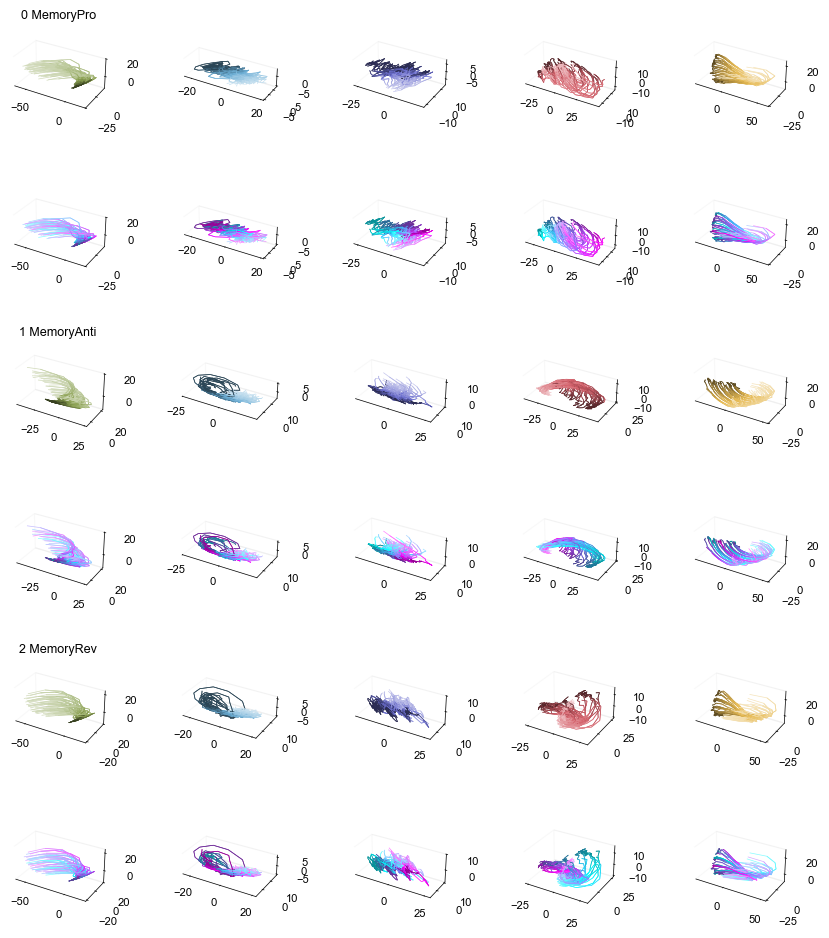

In [94]:
def _plot():
    nbl = len(test_data["block_slices"])
    fig, axes = plt.subplots(
        2 * nbl, 5, figsize=(2 * 5, 2 * 2 * nbl), subplot_kw={"projection": "3d"}, gridspec_kw={'wspace': 0.8}
    )
    for i_b, task in enumerate(test_data["block_tasks"]):
            ax = axes[2 * i_b : 2 * i_b + 2]
            angle_timepals = [angle_timepal(c) for c in trial_colors[i_b]]

            plot_n = 50
            for i_win in [1]:
                for i_per in range(5):
                    # trials[key][i_trial][i_period, i_in_window][..., i_pc, i_pca]
                    tcolor = [
                        period_timepals[i_b][int(t[i_per, i_win])]
                        for t in sum_trials[i_b]["period"][:plot_n]
                        if t[i_per, i_win] is not None
                    ]
                    tdata = [
                        t[i_per, i_win][..., :3, i_per]
                        for it, t in enumerate(sum_trials[i_b]["actpc"][:plot_n])
                        if sum_trials[i_b]["period"][it][i_per, i_win] is not None
                    ]
                    vd.trajecories(
                        ax[0, i_per],
                        tdata,
                        tcolor,
                        color="both",
                        lw=0.5,
                    )

                    vd.trajecories(
                        ax[1, i_per],
                        tdata,
                        angle_timepals[:plot_n],
                        color="both",
                        lw=0.5,
                    )

            ax[0, 0].set_title(f"{i_b} {task.name}")
    return fig


_fig = _plot()
plotter.finalize(_fig, "true-sum-traj_period-pca_3d")

/Users/kaifox/projects/mplutils/mplutil/nb.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


/Users/kaifox/projects/loop/dynrn/plots/notebook/multi-pred-failure/mems-def-long-lr20-w256_7d4c5e/true-sum-traj_full-pca_3d.pdf


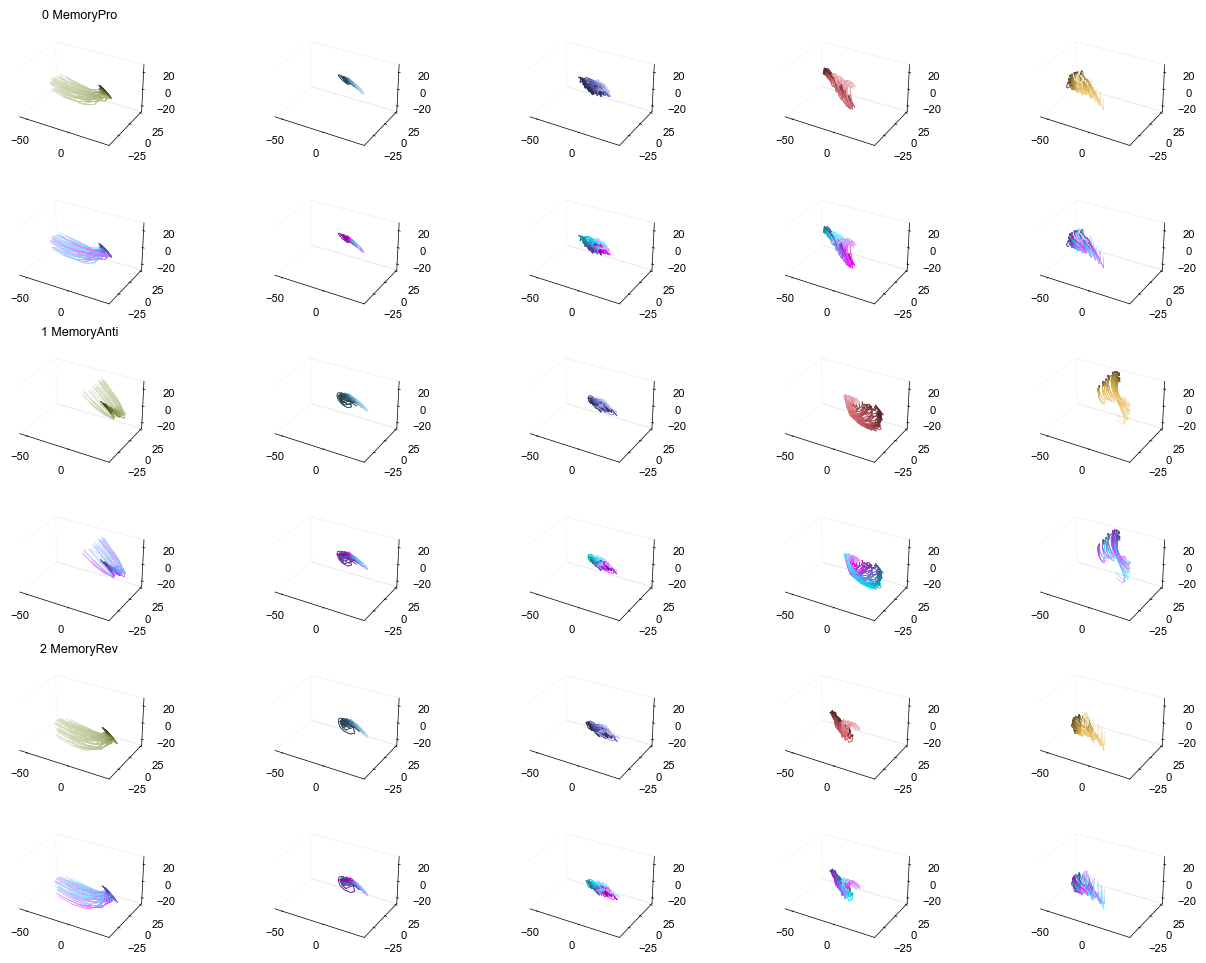

In [95]:
def _plot():
    nbl = len(test_data["block_slices"])
    fig, axes = plt.subplots(
        2 * nbl, 5, figsize=(3 * 5, 2 * 2 * nbl), subplot_kw={"projection": "3d"}, gridspec_kw={'wspace': 0.8}
    )
    xmin, xmax = np.inf, -np.inf
    ymin, ymax = np.inf, -np.inf
    zmin, zmax = np.inf, -np.inf
    for i_b, task in enumerate(test_data["block_tasks"]):
            ax = axes[2 * i_b : 2 * i_b + 2]
            angle_timepals = [angle_timepal(c) for c in trial_colors[i_b]]

            plot_n = 50
            for i_win in [1]:
                for i_per in range(5):
                    # sum_trials[key][i_trial][i_period, i_in_window][..., i_pc, i_pca]
                    tcolor = [
                        period_timepals[i_b][int(t[i_per, i_win])]
                        for t in sum_trials[i_b]["period"][:plot_n]
                        if t[i_per, i_win] is not None
                    ]
                    tdata = [
                        t[i_per, i_win][..., :3]
                        for it, t in enumerate(sum_trials[i_b]["factpc"][:plot_n])
                        if sum_trials[i_b]["period"][it][i_per, i_win] is not None
                    ]
                    xmin = min(xmin, min(t[:, 0].min() for t in tdata))
                    xmax = max(xmax, max(t[:, 0].max() for t in tdata))
                    ymin = min(ymin, min(t[:, 1].min() for t in tdata))
                    ymax = max(ymax, max(t[:, 1].max() for t in tdata))
                    zmin = min(zmin, min(t[:, 2].min() for t in tdata))
                    zmax = max(zmax, max(t[:, 2].max() for t in tdata))
                    vd.trajecories(
                        ax[0, i_per],
                        tdata,
                        tcolor,
                        color="both",
                        lw=0.5,
                        set_lim=False
                    )
                    vd.trajecories(
                        ax[1, i_per],
                        tdata,
                        angle_timepals[:plot_n],
                        color="both",
                        lw=0.5,
                        set_lim=False
                    )
                    # ax[0, i_per].view_init(15, -10)
                    # ax[1, i_per].view_init(15, -10)

            ax[0, 0].set_title(f"{i_b} {task.name}")

    for a in axes.ravel():
        a.set_xlim(xmin, xmax)
        a.set_ylim(ymin, ymax)
        a.set_zlim(zmin, zmax)
        a.set_box_aspect([xmax - xmin, ymax - ymin, zmax - zmin])
    return fig


_fig = _plot()
plotter.finalize(_fig, "true-sum-traj_full-pca_3d")

### Period-wise prediction dynamics: cumulant

/Users/kaifox/projects/mplutils/mplutil/nb.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


/Users/kaifox/projects/loop/dynrn/plots/notebook/multi-pred-failure/mems-def-long-lr20-w256_7d4c5e/pred-traj_full-pca_3d.pdf


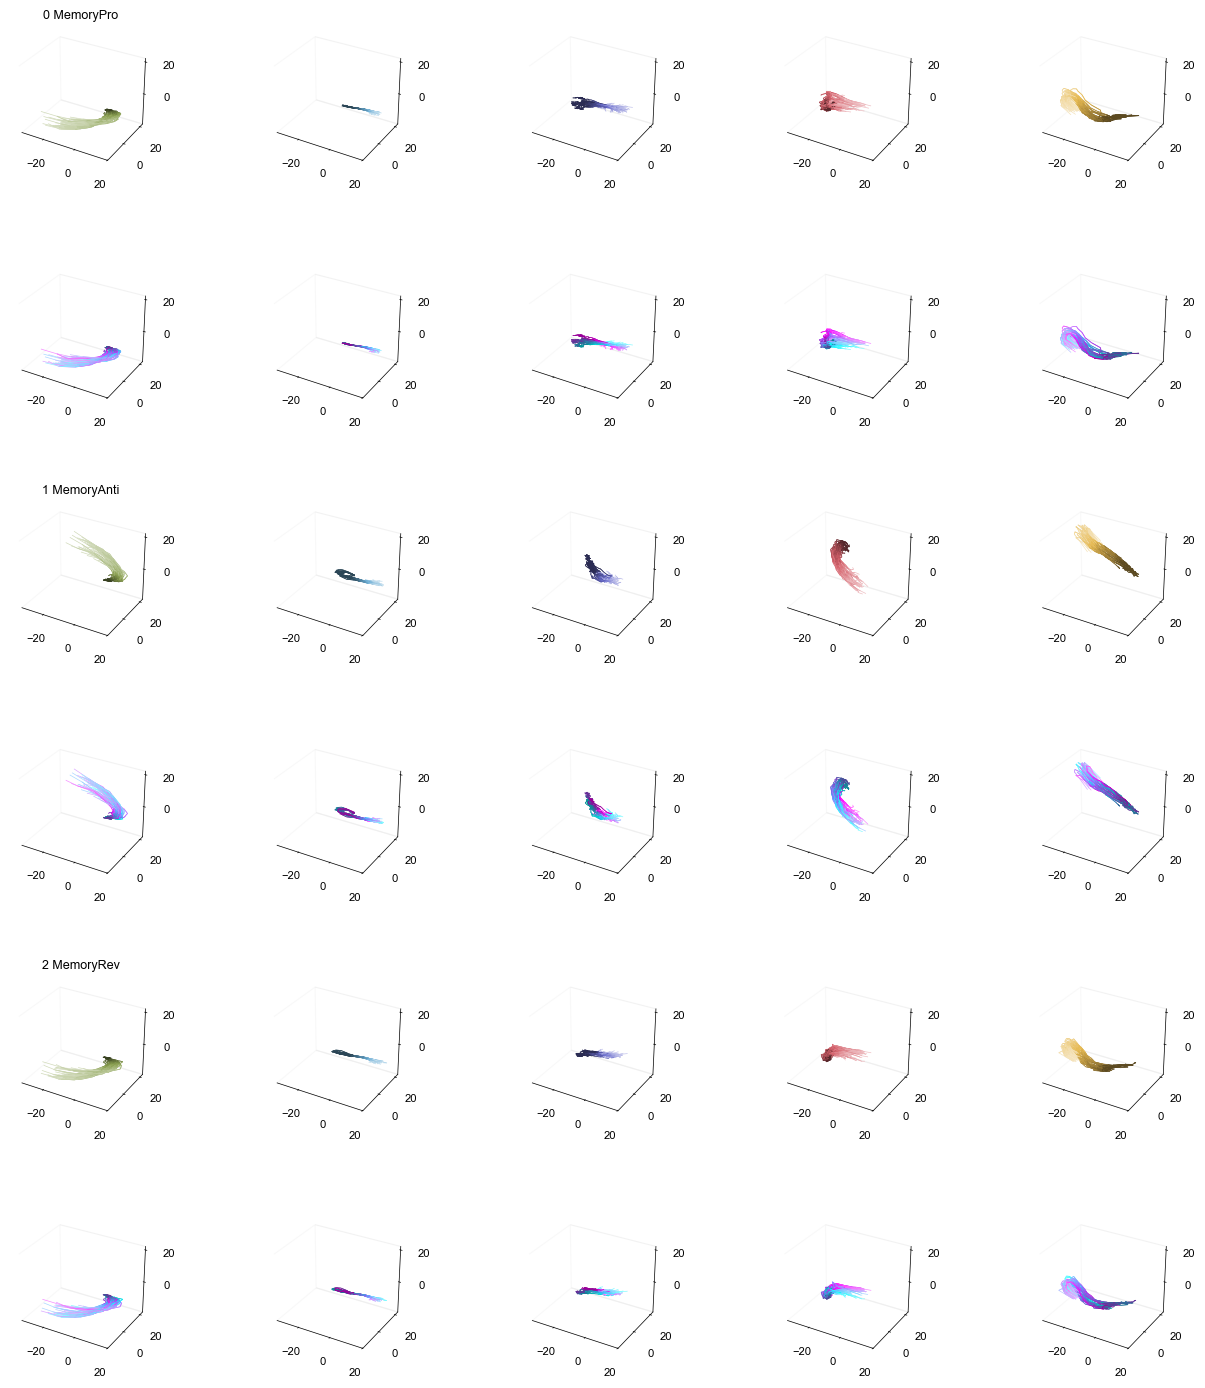

In [96]:
def _plot():
    nbl = len(test_data["block_slices"])
    fig, axes = plt.subplots(
        2 * nbl, 5, figsize=(3 * 5, 2 * 3 * nbl), subplot_kw={"projection": "3d"}, gridspec_kw={'wspace': 0.8}
    )
    xmin, xmax = np.inf, -np.inf
    ymin, ymax = np.inf, -np.inf
    zmin, zmax = np.inf, -np.inf
    for i_b, task in enumerate(test_data["block_tasks"]):
            ax = axes[2 * i_b : 2 * i_b + 2]
            angle_timepals = [angle_timepal(c) for c in trial_colors[i_b]]

            plot_n = 50
            for i_win in [1]:
                for i_per in range(5):
                    # trials[key][i_trial][i_period, i_in_window][..., i_pc, i_pca]
                    tcolor = [
                        period_timepals[i_b][int(t[i_per, i_win])]
                        for t in trials[i_b]["period"][:plot_n]
                        if t[i_per, i_win] is not None
                    ]
                    tdata = [
                        t[i_per, i_win][..., :3]
                        for it, t in enumerate(trials[i_b]["practfpc"][:plot_n])
                        if trials[i_b]["period"][it][i_per, i_win] is not None
                    ]
                    xmin = min(xmin, min(t[:, 0].min() for t in tdata))
                    xmax = max(xmax, max(t[:, 0].max() for t in tdata))
                    ymin = min(ymin, min(t[:, 1].min() for t in tdata))
                    ymax = max(ymax, max(t[:, 1].max() for t in tdata))
                    zmin = min(zmin, min(t[:, 2].min() for t in tdata))
                    zmax = max(zmax, max(t[:, 2].max() for t in tdata))
                    vd.trajecories(
                        ax[0, i_per],
                        tdata,
                        tcolor,
                        color="both",
                        lw=0.5,
                        set_lim=False
                    )
                    vd.trajecories(
                        ax[1, i_per],
                        tdata,
                        angle_timepals[:plot_n],
                        color="both",
                        lw=0.5,
                        set_lim=False
                    )

            ax[0, 0].set_title(f"{i_b} {task.name}")

    for a in axes.ravel():
        a.set_xlim(xmin, xmax)
        a.set_ylim(ymin, ymax)
        a.set_zlim(zmin, zmax)
        a.set_box_aspect([xmax - xmin, ymax - ymin, zmax - zmin])
    return fig


_fig = _plot()
plotter.finalize(_fig, "pred-traj_full-pca_3d")

/Users/kaifox/projects/mplutils/mplutil/nb.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


/Users/kaifox/projects/loop/dynrn/plots/notebook/multi-pred-failure/mems-def-long-lr20-w256_7d4c5e/pred-traj_period-pca_3d.pdf


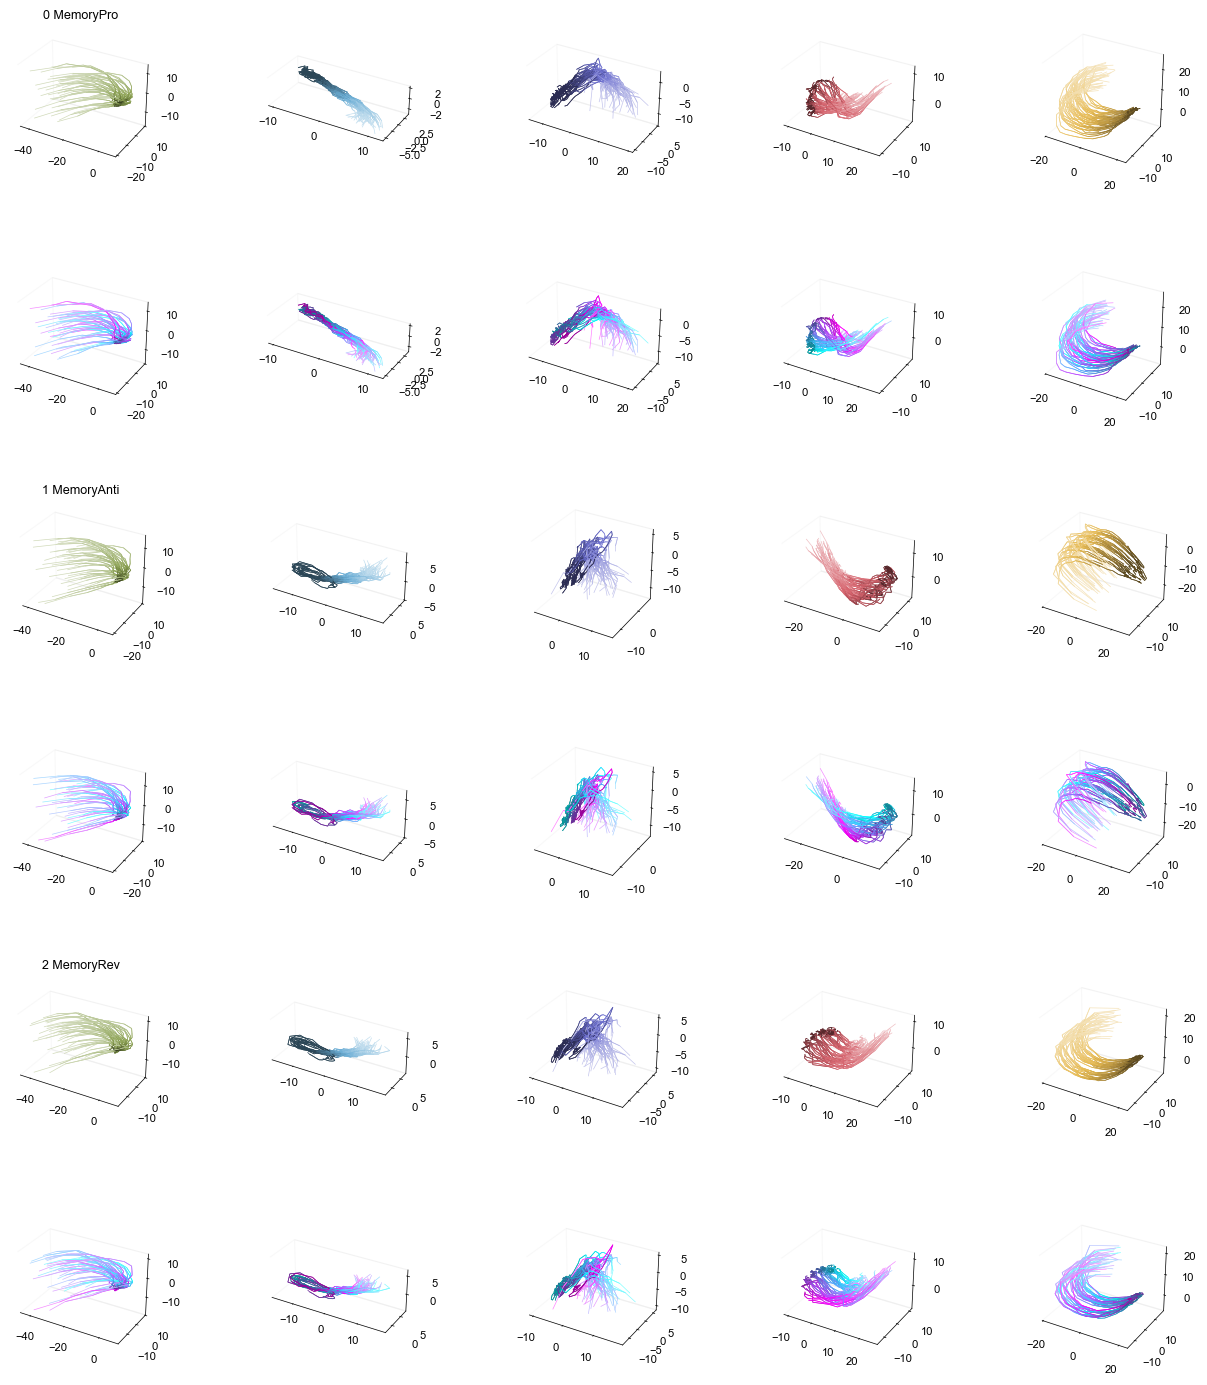

In [97]:
def _plot():
    nbl = len(test_data["block_slices"])
    fig, axes = plt.subplots(
        2 * nbl, 5, figsize=(3 * 5, 2 * 3 * nbl), subplot_kw={"projection": "3d"}, gridspec_kw={'wspace': 0.8}
    )
    xmin, xmax = np.inf, -np.inf
    ymin, ymax = np.inf, -np.inf
    zmin, zmax = np.inf, -np.inf
    for i_b, task in enumerate(test_data["block_tasks"]):
            ax = axes[2 * i_b : 2 * i_b + 2]
            angle_timepals = [angle_timepal(c) for c in trial_colors[i_b]]

            plot_n = 50
            for i_win in [1]:
                for i_per in range(5):
                    # trials[key][i_trial][i_period, i_in_window][..., i_pc, i_pca]
                    tcolor = [
                        period_timepals[i_b][int(t[i_per, i_win])]
                        for t in trials[i_b]["period"][:plot_n]
                        if t[i_per, i_win] is not None
                    ]
                    tdata = [
                        t[i_per, i_win][..., :3, i_per]
                        for it, t in enumerate(trials[i_b]["practpc"][:plot_n])
                        if trials[i_b]["period"][it][i_per, i_win] is not None
                    ]
                    xmin = min(xmin, min(t[:, 0].min() for t in tdata))
                    xmax = max(xmax, max(t[:, 0].max() for t in tdata))
                    ymin = min(ymin, min(t[:, 1].min() for t in tdata))
                    ymax = max(ymax, max(t[:, 1].max() for t in tdata))
                    zmin = min(zmin, min(t[:, 2].min() for t in tdata))
                    zmax = max(zmax, max(t[:, 2].max() for t in tdata))
                    vd.trajecories(
                        ax[0, i_per],
                        tdata,
                        tcolor,
                        color="both",
                        lw=0.5,
                    )
                    vd.trajecories(
                        ax[1, i_per],
                        tdata,
                        angle_timepals[:plot_n],
                        color="both",
                        lw=0.5,
                    )

            ax[0, 0].set_title(f"{i_b} {task.name}")

    return fig


_fig = _plot()
plotter.finalize(_fig, "pred-traj_period-pca_3d")

### Period-wise prediction plots: sums

/Users/kaifox/projects/mplutils/mplutil/nb.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


/Users/kaifox/projects/loop/dynrn/plots/notebook/multi-pred-failure/mems-def-long-lr20-w256_7d4c5e/pred-sum-traj_full-pca_3d.pdf


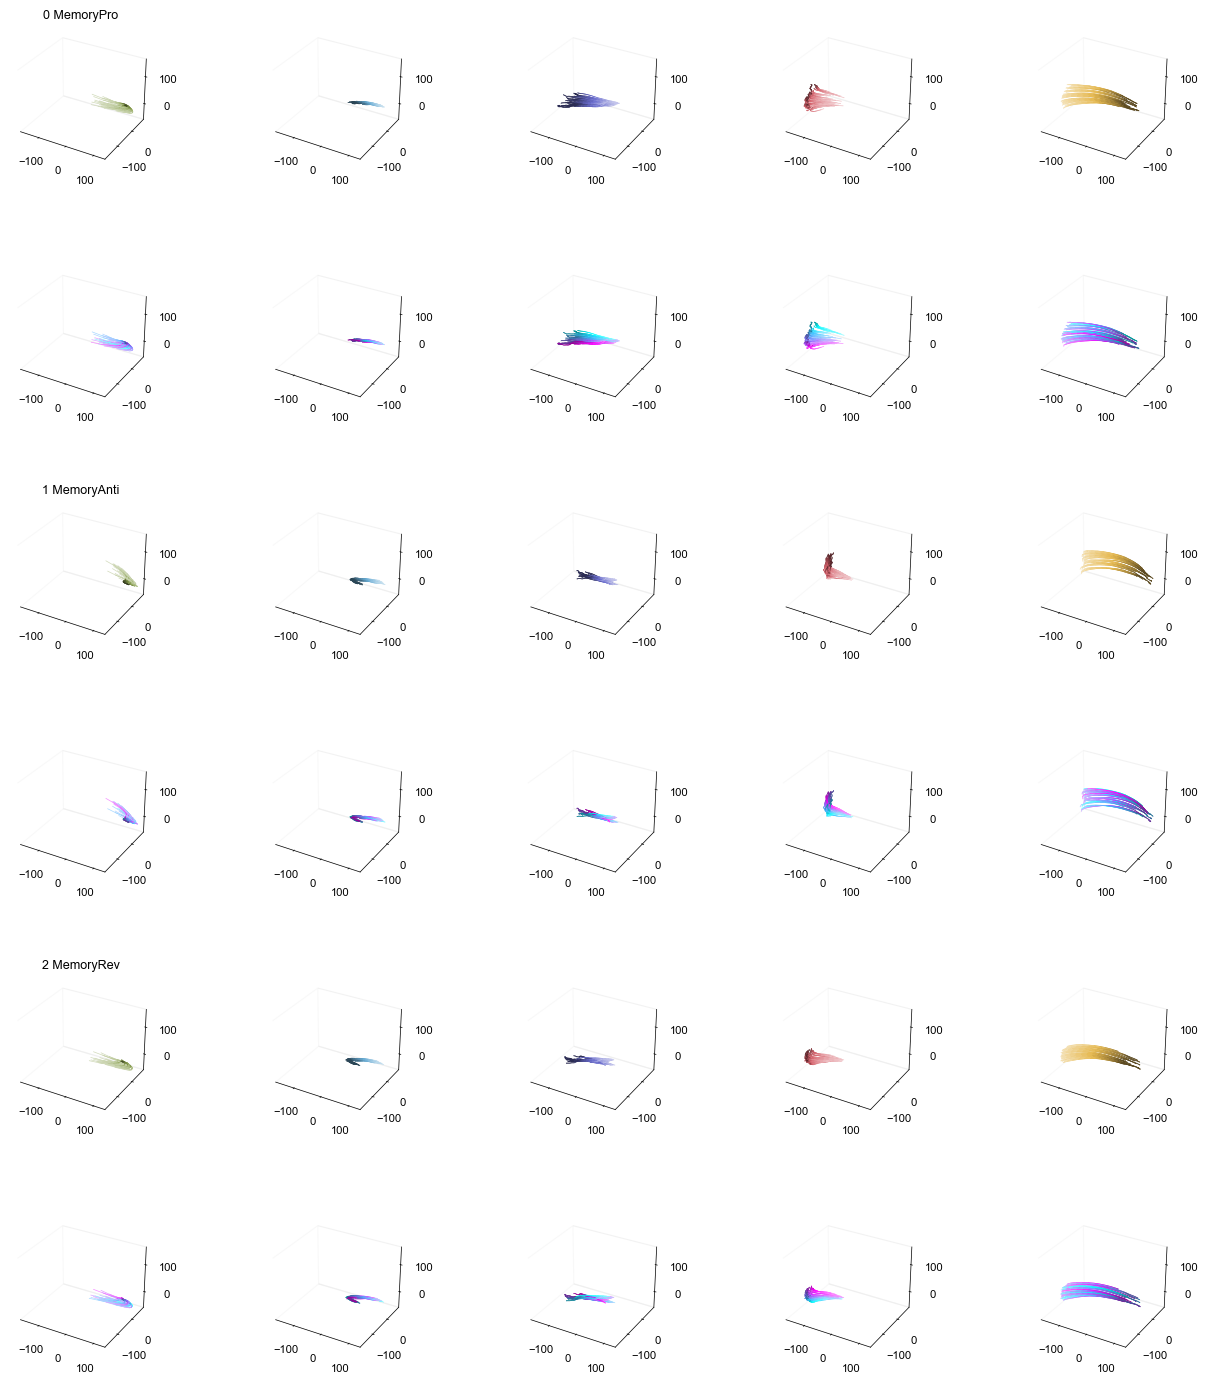

In [98]:
def _plot():
    nbl = len(test_data["block_slices"])
    fig, axes = plt.subplots(
        2 * nbl, 5, figsize=(3 * 5, 2 * 3 * nbl), subplot_kw={"projection": "3d"}, gridspec_kw={'wspace': 0.8}
    )
    xmin, xmax = np.inf, -np.inf
    ymin, ymax = np.inf, -np.inf
    zmin, zmax = np.inf, -np.inf
    for i_b, task in enumerate(test_data["block_tasks"]):
            ax = axes[2 * i_b : 2 * i_b + 2]
            angle_timepals = [angle_timepal(c) for c in trial_colors[i_b]]

            plot_n = 50
            for i_win in [1]:
                for i_per in range(5):
                    # sum_trials[key][i_trial][i_period, i_in_window][..., i_pc, i_pca]
                    tcolor = [
                        period_timepals[i_b][int(t[i_per, i_win])]
                        for t in sum_trials[i_b]["period"][:plot_n]
                        if t[i_per, i_win] is not None
                    ]
                    tdata = [
                        t[i_per, i_win][..., :3]
                        for it, t in enumerate(sum_trials[i_b]["practfpc"][:plot_n])
                        if sum_trials[i_b]["period"][it][i_per, i_win] is not None
                    ]
                    xmin = min(xmin, min(t[:, 0].min() for t in tdata))
                    xmax = max(xmax, max(t[:, 0].max() for t in tdata))
                    ymin = min(ymin, min(t[:, 1].min() for t in tdata))
                    ymax = max(ymax, max(t[:, 1].max() for t in tdata))
                    zmin = min(zmin, min(t[:, 2].min() for t in tdata))
                    zmax = max(zmax, max(t[:, 2].max() for t in tdata))
                    vd.trajecories(
                        ax[0, i_per],
                        tdata,
                        tcolor,
                        color="both",
                        lw=0.5,
                        set_lim=False
                    )
                    vd.trajecories(
                        ax[1, i_per],
                        tdata,
                        angle_timepals[:plot_n],
                        color="both",
                        lw=0.5,
                        set_lim=False
                    )

            ax[0, 0].set_title(f"{i_b} {task.name}")

    for a in axes.ravel():
        a.set_xlim(xmin, xmax)
        a.set_ylim(ymin, ymax)
        a.set_zlim(zmin, zmax)
        a.set_box_aspect([xmax - xmin, ymax - ymin, zmax - zmin])
    return fig


_fig = _plot()
plotter.finalize(_fig, "pred-sum-traj_full-pca_3d")

/Users/kaifox/projects/mplutils/mplutil/nb.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


/Users/kaifox/projects/loop/dynrn/plots/notebook/multi-pred-failure/mems-def-long-lr20-w256_7d4c5e/pred-sum-traj_period-pca_3d.pdf


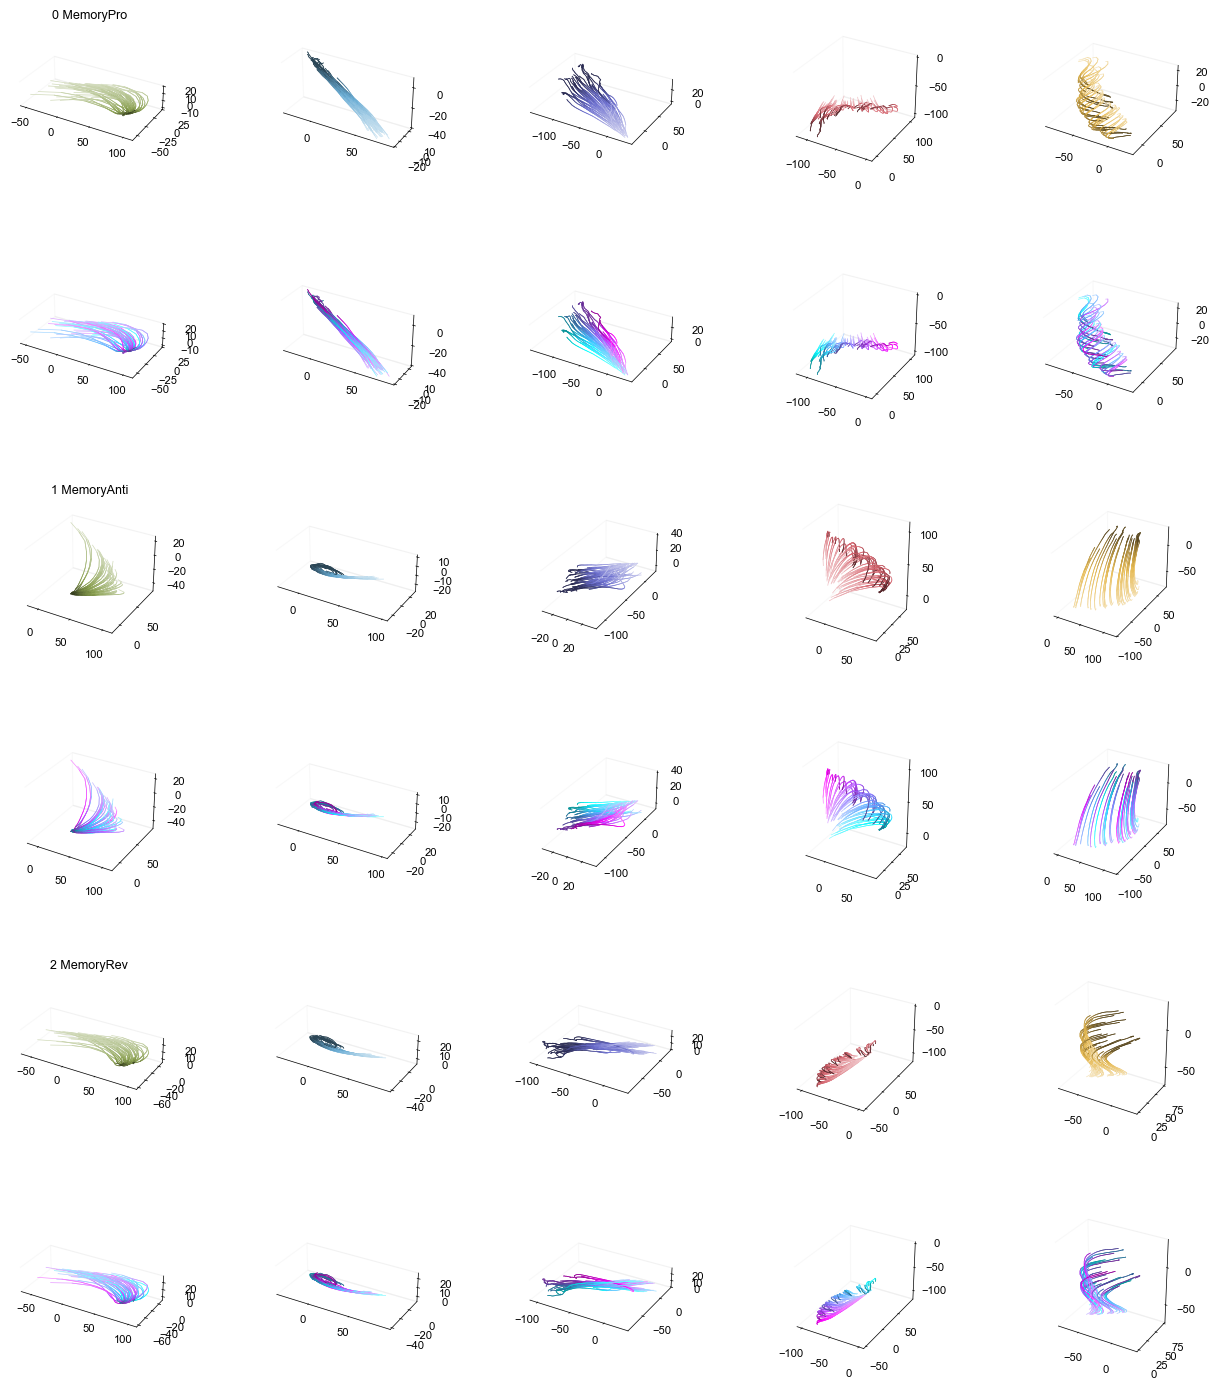

In [99]:
def _plot():
    nbl = len(test_data["block_slices"])
    fig, axes = plt.subplots(
        2 * nbl, 5, figsize=(3 * 5, 2 * 3 * nbl), subplot_kw={"projection": "3d"}, gridspec_kw={'wspace': 0.8}
    )
    xmin, xmax = np.inf, -np.inf
    ymin, ymax = np.inf, -np.inf
    zmin, zmax = np.inf, -np.inf
    for i_b, task in enumerate(test_data["block_tasks"]):
            ax = axes[2 * i_b : 2 * i_b + 2]
            angle_timepals = [angle_timepal(c) for c in trial_colors[i_b]]

            plot_n = 50
            for i_win in [1]:
                for i_per in range(5):
                    # sum_trials[key][i_trial][i_period, i_in_window][..., i_pc, i_pca]
                    tcolor = [
                        period_timepals[i_b][int(t[i_per, i_win])]
                        for t in sum_trials[i_b]["period"][:plot_n]
                        if t[i_per, i_win] is not None
                    ]
                    tdata = [
                        t[i_per, i_win][..., :3, i_per]
                        for it, t in enumerate(sum_trials[i_b]["practpc"][:plot_n])
                        if sum_trials[i_b]["period"][it][i_per, i_win] is not None
                    ]
                    xmin = min(xmin, min(t[:, 0].min() for t in tdata))
                    xmax = max(xmax, max(t[:, 0].max() for t in tdata))
                    ymin = min(ymin, min(t[:, 1].min() for t in tdata))
                    ymax = max(ymax, max(t[:, 1].max() for t in tdata))
                    zmin = min(zmin, min(t[:, 2].min() for t in tdata))
                    zmax = max(zmax, max(t[:, 2].max() for t in tdata))
                    vd.trajecories(
                        ax[0, i_per],
                        tdata,
                        tcolor,
                        color="both",
                        lw=0.5,
                    )
                    vd.trajecories(
                        ax[1, i_per],
                        tdata,
                        angle_timepals[:plot_n],
                        color="both",
                        lw=0.5,
                    )

            ax[0, 0].set_title(f"{i_b} {task.name}")

    return fig


_fig = _plot()
plotter.finalize(_fig, "pred-sum-traj_period-pca_3d")

### True v. prediction comparison